# imports

In [183]:
import numpy as np
import pandas as pd
import hypertools as hyp
import pickle
import os
import cortex
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
import importlib.util
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# %config InlineBackend.figure_format = 'retina'

# set paths

In [3]:
annot_dir = '../../data/annotations_dfs/'
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings', 'k:1000')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:1000')
pickle_dir = '../../data/pickles/'
braindata_dir = '../../data/brains/'
fig_dir = '../../figures/'
brainfig_dir = os.path.join(fig_dir,'brains/')

# load data

In [137]:
with open(pickle_dir+'fit_models.p', 'rb') as f:
    models_dict = pickle.load(f)
    
brainweights = np.load(braindata_dir+'HuthModelWeights.npy')
mask = np.load(braindata_dir+'mask.npy')

# load neural speech representation semantic model 

In [207]:
# credit: https://github.com/HuthLab/speechmodeltutorial
spec = importlib.util.spec_from_file_location('HuthSpeechModel', '../HuthSpeechModel/SemanticModel.py')
HSM = importlib.util.module_from_spec(spec)
spec.loader.exec_module(HSM)
corpus = HSM.SemanticModel.load('../HuthSpeechModel/data/english1000sm.hf5')

In [208]:
# percent of words in episode corpus covered in Huth semantic model
for episode in models_dict.keys():
    if episode != 'delayed':
        nwords_covered = len([i for i in list(models_dict[episode]['cv'].vocabulary_) if i in corpus.vocab])
        print('{0}: {1}% coverage'.format(episode, nwords_covered/len(list(models_dict[episode]['cv'].vocabulary_))))

atlep1: 0.7756132756132756% coverage
atlep2: 0.7621178225205071% coverage
arrdev: 0.7450372208436724% coverage


In [246]:
for episode, mods in models_dict.items():
    if episode != 'delayed':
        # get distribution of word weights for each topic
        topic_wordweights = mods['tm'].components_ / mods['tm'].components_.sum(axis=1)[:, np.newaxis]

        # voxel responses for each word in the corpus
        word_activations = {}
        # for each word in the episode
        for word in mods['cv'].vocabulary_:

            # if it's in the Huth model's vocab, use its weights
            if word in corpus.vocab:
                wordweight = corpus[word]
            # otherwise fill with nans
            else:
                wordweight = np.full(985, np.nan)

            # get voxel-wise response for word weight
            voxweights = np.dot(wordweight, brainweights)
            word_activations[word] = voxweights
        break
        weighted_activations = ()

In [288]:
topic_wordweights.shape

(100, 1386)

In [287]:
np.array(list(word_activations.values())).shape

(1386, 37226)

In [285]:
np.array(list(word_activations.values()))[0] * topic_wordweights

ValueError: operands could not be broadcast together with shapes (37226,) (100,1386) 

In [299]:
np.multiply(np.atleast_2d(topic_wordweights[0]), np.array(list(word_activations.values())))

ValueError: operands could not be broadcast together with shapes (1,1386) (1386,37226) 

In [294]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])
b = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])

In [295]:
np.multiply(a,b)

array([[ 1,  4,  9, 16],
       [25, 36, 49, 64]])

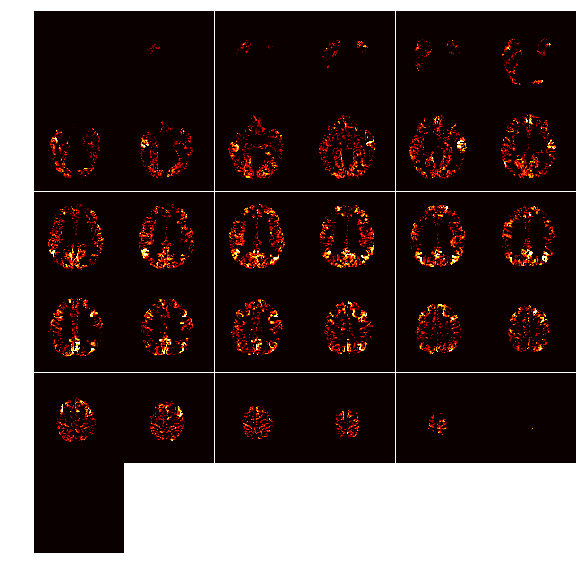

In [149]:
corrvolume = np.zeros(mask.shape)
corrvolume[mask>0] = voxweights

f = plt.figure(figsize=(10,10))
cortex.mosaic(corrvolume, vmin=0, vmax=.1, cmap='hot');

In [167]:
voxweights.shape

(37226,)

In [161]:
models_dict['atlep1'].keys()

dict_keys(['cv', 'fit_cv', 'tm', 'norm_ep_events', 'norm_avg_rec_events'])

In [40]:
fit_cv = models_dict['atlep1']['fit_cv']

In [39]:
cv = models_dict['atlep1']['cv']

In [63]:
tm = models_dict['atlep1']['tm']

In [163]:
models_dict['atlep1']['norm_ep_events'].shape

(32, 1386)

In [68]:
len(cv.vocabulary_.keys())

1386

In [169]:
tm.components_.shape

(100, 1386)

In [177]:
(tm.components_ / tm.components_.sum(axis=1)[:, np.newaxis]).shape

(100, 1386)

In [117]:
for i in cv.vocabulary_:
    print(i)

alfred
paper
boy
sitting
car
foot
kicks
view
mirror
turns
exclaims
surprised
angry
outdoor
convenience
store
parking
lot
darius
open
doors
man
woman
walk
away
yells
really
hey
steps
earn
concerned
slams
door
asking
money
broken
gonna
need
cash
calls
worried
walks
confronts
gets
runs
hello
tries
attention
trying
calm
know
hear
catch
shouts
talking
speaking
english
touches
chest
asks
stay
relaxed
diffuse
situation
alright
cool
let
just
okay
guys
threatens
escalating
nigga
don
face
voice
background
worldstar
tells
person
shouted
stop
think
fair
calmly
compensation
bruh
refuses
staying
broke
tonight
reason
look
club
pointing
poor
wants
trouble
looks
means
stunting
anybody
speaks
antagonizes
mocks
shut
rude
tensions
rise
bitch
hell
talk
way
offended
like
defends
offers
settle
problems
demands
want
got
problem
involved
hold
cuz
interjects
says
having
deja
vu
dog
spots
texas
turn
getting
crazy
right
finds
points
experiencing
street
sits
grass
comments
confused
trip
patch
wrong
yo
holds
change

In [122]:
corpus['hello']

array([-9.36985638e-02,  9.95956817e-02, -5.78146667e-01, -4.46107486e-01,
       -5.69587106e-01, -9.50641900e-01, -1.41453662e+00,  8.67824594e-01,
        4.64126105e-01, -6.03063394e-01,  9.13677875e-01, -5.32536666e-01,
        3.98694232e-01,  6.45003514e-02, -7.38703733e-01, -8.56260000e-02,
       -1.18285325e-01, -5.88200985e-01, -1.33275758e-01,  3.19782726e-01,
        2.08205101e+00, -6.65280127e-01, -3.01745120e-01, -3.77312519e-01,
        3.47387360e-01, -9.15644890e-02,  1.56866795e+00, -3.30327839e-01,
        9.05082569e-01,  7.22615031e-01,  1.75310058e-01,  9.07057818e-03,
       -4.67569669e-02, -1.00226759e+00,  1.67378900e-01, -1.42851422e+00,
       -3.89112538e-02, -3.98285159e-01, -5.41310678e-01, -6.47500679e-01,
        1.49744862e+00, -2.37817092e-01, -1.08147150e+00,  8.38167517e-01,
       -7.23646216e-01,  3.21996901e-02,  2.56395263e+00,  6.02541837e-01,
        4.37505066e-01,  7.85565723e-01, -6.20991685e-02,  2.50305260e-02,
       -6.61788068e-01,  

In [123]:
corpus.project_stims([['hello']])

array([[-9.36985638e-02,  9.95956817e-02, -5.78146667e-01,
        -4.46107486e-01, -5.69587106e-01, -9.50641900e-01,
        -1.41453662e+00,  8.67824594e-01,  4.64126105e-01,
        -6.03063394e-01,  9.13677875e-01, -5.32536666e-01,
         3.98694232e-01,  6.45003514e-02, -7.38703733e-01,
        -8.56260000e-02, -1.18285325e-01, -5.88200985e-01,
        -1.33275758e-01,  3.19782726e-01,  2.08205101e+00,
        -6.65280127e-01, -3.01745120e-01, -3.77312519e-01,
         3.47387360e-01, -9.15644890e-02,  1.56866795e+00,
        -3.30327839e-01,  9.05082569e-01,  7.22615031e-01,
         1.75310058e-01,  9.07057818e-03, -4.67569669e-02,
        -1.00226759e+00,  1.67378900e-01, -1.42851422e+00,
        -3.89112538e-02, -3.98285159e-01, -5.41310678e-01,
        -6.47500679e-01,  1.49744862e+00, -2.37817092e-01,
        -1.08147150e+00,  8.38167517e-01, -7.23646216e-01,
         3.21996901e-02,  2.56395263e+00,  6.02541837e-01,
         4.37505066e-01,  7.85565723e-01, -6.20991685e-0